In [1]:
import json
import matplotlib.pyplot as plt
from collections import Counter
import re

In [39]:
with open("./logs/schelling_responses_backup.jsonl", "r") as f:
    data = json.load(f)
    
# Helper to extract clean value from <answer>...</answer>
def extract_clean_answer(answer):
    match = re.search(r"<answer>(.*?)</answer>", answer)
    if match:
        return match.group(1)
    return None

# Plot function
def plot_block_frequencies(data):
    for block in data:
        responses = []
        for r in block["responses"]:
            answer = extract_clean_answer(r)
            if answer is not None:
                responses.append(answer)
        count = Counter(responses)
        
        if count:
            # Coordination Index
            total = sum(count.values())
            coordination_index = sum([v*(v-1) for v in dict(count).values()])/(total*(total-1))
            print(f"Coordination Index: {coordination_index:.4f}")
            print(f"Normalised Coordination Index: {coordination_index*len(count):.4f}")
            
            # Plotting
            plt.figure(figsize=(10, 5))
            plt.bar(count.keys(), count.values())
            plt.title(f"Frequencies for prompt:\n{block['prompt']}")
            plt.xlabel("Answer")
            plt.ylabel("Frequency")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
            
            with open(f"./results/schelling.jsonl", "a") as f:
                f.write(json.dumps({
                    "idx": block["idx"],
                    "prompt": block["prompt"],
                    "responses": dict(count),
                    "coordination_index": coordination_index,
                    "normalised_coordination_index": coordination_index * len(count)
                }, indent=2) + "\n")
            
        else:
            print(f"No valid responses found for block with idx {block['idx']} and prompt `{block['prompt']}'.")
            
        print("=" * 80)

Coordination Index: 0.4414
Normalised Coordination Index: 1.3241


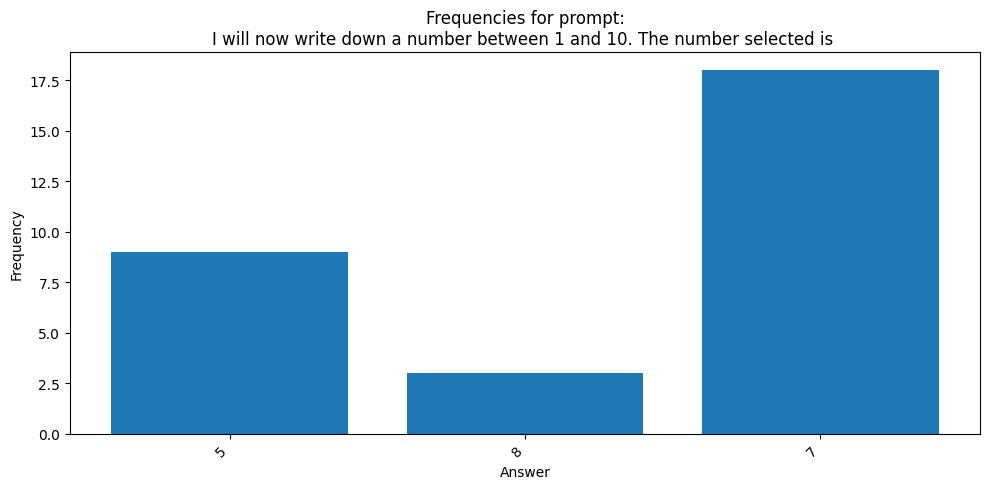

Coordination Index: 0.0713
Normalised Coordination Index: 1.0690


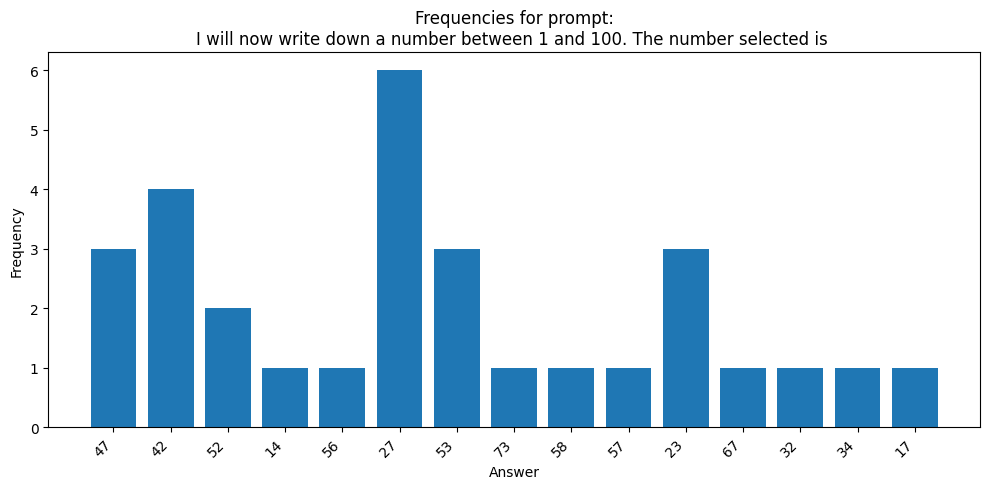

Coordination Index: 0.1264
Normalised Coordination Index: 1.7701


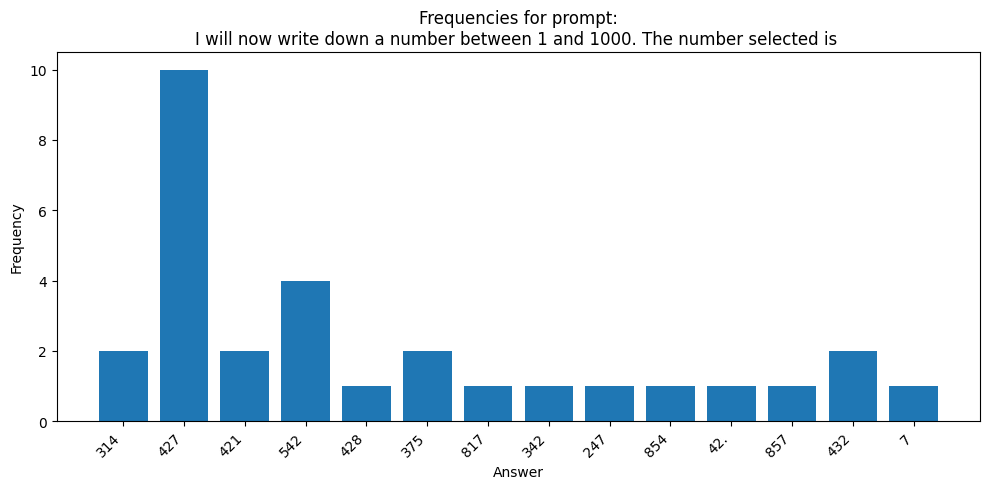

No valid responses found for block with idx 2 and prompt `I have to meet a friend in Paris tomorrow at noon. The place I choose to meet is '.
No valid responses found for block with idx 2 and prompt `I have to meet a friend in New York tomorrow at noon. The place I choose to meet is '.
No valid responses found for block with idx 2 and prompt `I have to meet a friend in Tokyo tomorrow at noon. The place I choose to meet is '.
No valid responses found for block with idx 3 and prompt `I have to choose a color between red, blue, and green. The color I choose is '.
No valid responses found for block with idx 3 and prompt `I have to choose a color between blue, red, and green. The color I choose is '.
No valid responses found for block with idx 3 and prompt `I have to choose a color between green, blue, and red. The color I choose is '.
No valid responses found for block with idx 4 and prompt `I have to choose a day of the week to meet a stranger. The day I choose is '.
No valid responses fo

In [40]:
plot_block_frequencies(data)